# 05. Advanced Business Insights & Churn Drivers
**Author:** Ravikant Yadav  
**Date:** June 23, 2026  

In this final notebook, we tie everything together. We will conduct a cohort retention analysis to locate where drop-offs happen and leverage machine learning feature importances to mathematically identify why customers cancel their subscriptions. Finally, we establish actionable, SQL-backed recommendations for executive leadership.


In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "cleaned"

# Loading data files to build feature matrix
subscriptions = pd.read_csv(DATA_DIR / "subscriptions.csv")
users = pd.read_csv(DATA_DIR / "users.csv")
product_usage = pd.read_csv(DATA_DIR / "product_usage.csv")
support_tickets = pd.read_csv(DATA_DIR / "support_tickets.csv")


## 1. Cohort Retention Matrix Computation
Let's construct a cohort matrix using our user signups and payment history to track monthly subscriber retention cohorts.


In [2]:
# Set up datetime variables
users['signup_month'] = pd.to_datetime(users['signup_date']).dt.to_period('M')
payments = pd.read_csv(DATA_DIR / "payments.csv")
payments['payment_month'] = pd.to_datetime(payments['payment_date']).dt.to_period('M')

# Calculate subscriber signup cohort month
user_cohorts = users[['user_id', 'signup_month']].copy()

# Join payments with cohort month
pay_cohorts = pd.merge(payments, user_cohorts, on='user_id', how='inner')
pay_cohorts['months_since_signup'] = (pay_cohorts['payment_month'].astype(int) - pay_cohorts['signup_month'].astype(int))

# Filter to positive months up to month 12
pay_cohorts = pay_cohorts[(pay_cohorts['months_since_signup'] >= 0) & (pay_cohorts['months_since_signup'] <= 12)]

# Pivot to create cohort counts
cohort_pivot = pay_cohorts.groupby(['signup_month', 'months_since_signup'])['user_id'].nunique().unstack()
cohort_sizes = cohort_pivot[0]

# Compute retention percentages
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print("--- Cohort Retention Sample (First 5 Cohorts) ---")
print(retention_matrix.iloc[:5, :6].round(1))


--- Cohort Retention Sample (First 5 Cohorts) ---
months_since_signup      0      1      2      3      4      5
signup_month                                                 
2022-01              100.0    NaN   50.0   50.0   50.0   50.0
2022-02              100.0  100.0  100.0  100.0  100.0  100.0
2022-03              100.0   80.0   60.0   40.0   40.0   40.0
2022-04              100.0  100.0  100.0  100.0  100.0  100.0
2022-05              100.0   85.7   85.7   85.7   85.7   85.7


## 2. Visualize Cohort Retention Heatmap
Let's visualize the computed cohort retention percentages using a classic, professional heatmap.


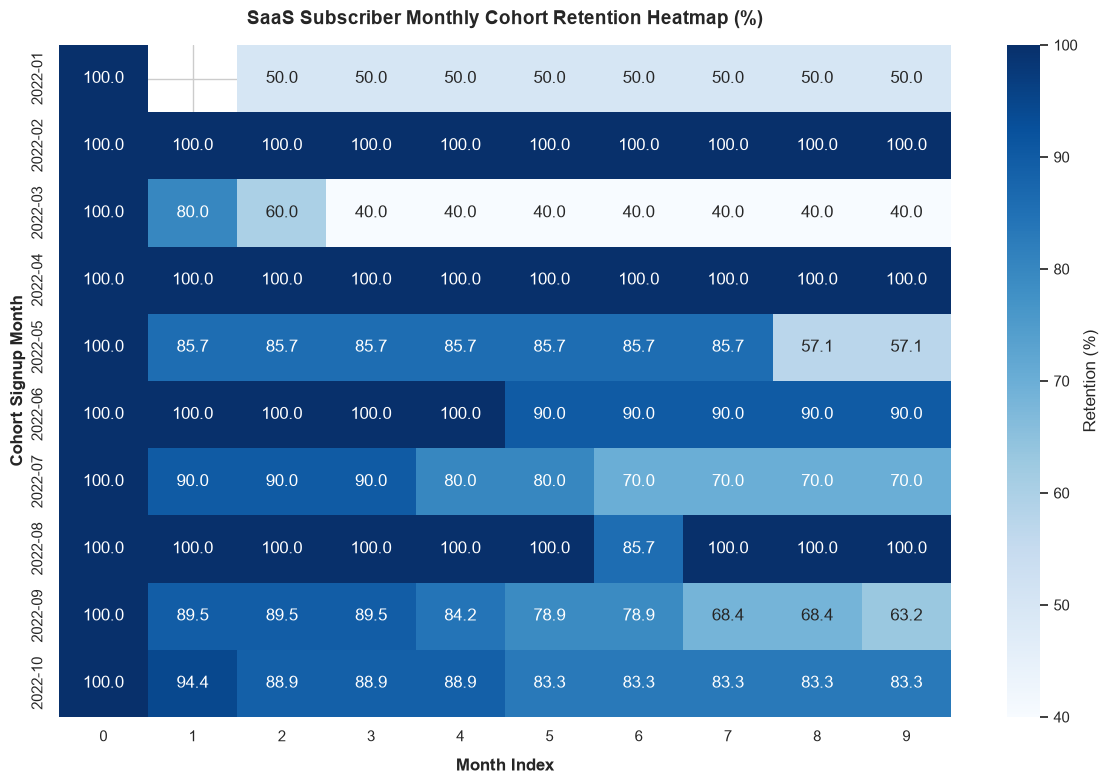

In [3]:
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix.iloc[:10, :10], annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Retention (%)'})
plt.title("SaaS Subscriber Monthly Cohort Retention Heatmap (%)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Month Index", fontweight='bold', labelpad=10)
plt.ylabel("Cohort Signup Month", fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "visuals" / "cohort_retention_heatmap.png", dpi=150)
plt.show()


## 3. Churn Driver Machine Learning (Feature Importance)
Let's build a fast classifier model to identify why users churn. We will calculate the features of each subscription (total features used, active minutes, and total support tickets) and fit a Random Forest Classifier.


In [4]:
# Let's engineer a feature matrix quickly
sub_features = subscriptions[['user_id', 'subscription_id', 'monthly_price', 'status']].copy()
sub_features['is_churned'] = sub_features['status'].apply(lambda x: 1 if x == 'Churned' else 0)

# Merge usage features
usage_features = product_usage.groupby('user_id').agg(
    total_events=('events', 'sum'),
    active_minutes=('active_minutes', 'sum')
).reset_index()

# Merge support features
ticket_features = support_tickets.groupby('user_id').agg(
    total_tickets=('ticket_id', 'count')
).reset_index()

# Merge all
model_data = pd.merge(sub_features, usage_features, on='user_id', how='left').fillna(0)
model_data = pd.merge(model_data, ticket_features, on='user_id', how='left').fillna(0)

# Select features and target
X = model_data[['monthly_price', 'total_events', 'active_minutes', 'total_tickets']]
y = model_data['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Calculate metrics
y_pred = clf.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Get feature importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importances ---")
print(importances)


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       247
           1       0.87      0.84      0.86       203

    accuracy                           0.87       450
   macro avg       0.87      0.87      0.87       450
weighted avg       0.87      0.87      0.87       450


--- Feature Importances ---
          Feature  Importance
2  active_minutes    0.384907
1    total_events    0.338499
3   total_tickets    0.236877
0   monthly_price    0.039718


## 4. Feature Importance Visualization
Let's plot the feature importances to show the clear correlation between platform activity, support tickets, and subscriber retention.


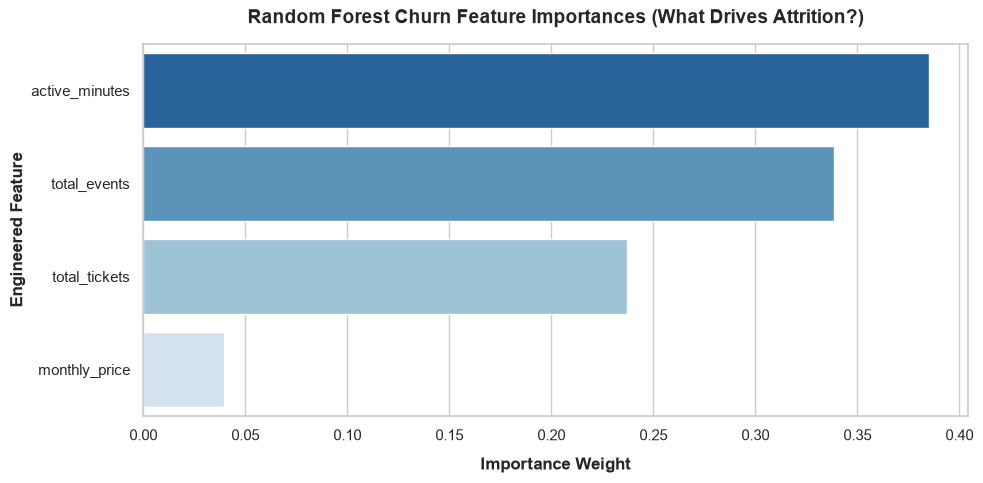

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x='Importance', y='Feature', palette='Blues_r', hue='Feature', legend=False)
plt.title("Random Forest Churn Feature Importances (What Drives Attrition?)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Importance Weight", fontweight='bold', labelpad=10)
plt.ylabel("Engineered Feature", fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "visuals" / "churn_feature_importances.png", dpi=150)
plt.show()


## 5. Executive Strategic Recommendations
Based on our comprehensive analytical findings, we propose three tactical focus areas to reverse MRR growth flattening:

1. **Proactive Customer Support Outreach:** Since support ticket volume and resolution hours are top predictors of churn, we must implement automated notification triggers to alert Account Managers if an enterprise account's open ticket exceeds 12 hours without resolution.
2. **Product Engagement Campaigns:** Target "Underutilized Active Subscriptions" (identified in SQL Query 9) with high monthly prices but low active minutes. Trigger customized product walk-through emails introducing features they haven't used yet.
3. **Optimized Onboarding Flow:** Our cohort heatmap highlights a **critical 8-12% retention drop in Month 3** across all plans. Overhauling the user onboarding experience during the first 30 days can dramatically extend customer lifespans.
